## Coordinate Frames ##

**Brief Overview of obtaining body frame**
- The inertial frame $\mathcal{F}^i$ is defined at global 0;0;0. Axes are pointed facing North East Down. defines:
    - position from GPS
    - Newton's equations
- The vehicle frame $\mathcal{F^v}$ is centered around the MAV with the the axis facing the same direction as the inertial frame
- vehicle-1 frame $\mathcal{F^{v1}}$ shares an origin with the $\mathcal{F^v}$, but is rotated in the right hand direction about the $k^{v}$ axis. This points $i^{v1}$ out the nose of the aircraft
- vehicle 2 frame $\mathcal{F^{v2}}$ is rotated along the $\mathcal{F^{v2}}$ frame. The $\mathcal{k^{v2}}$ frame is pointing out the belly of the MAV
- The body frame $\mathcal{F^b}$ is then rotated about $i^{v2}$ so that $j^b$ is facing out the right wing of the MAV

# Transfer Function Model #
## Lateral Equations ##
$\ddot{\phi} = \dot{p} + \dot{d}_{\phi 1}$  
$\ddot{\phi} = (\frac{1}{2}\rho V_a^2 S b C_{pp} \frac{b}{2 V_a})\dot{\phi} + (\frac{1}{2}\rho Va^2Sb)\delta_{a} + (\Tau_{1}pq - \Tau_{2}qr + \frac{1}{2}\rho V_a^2 Sb[C_{p0} + C_{p\beta}\beta - C_{pp}\frac{b}{2V_a}(d_{\phi1}) + C_{p\delta r}\delta_{r}]+\dot{d}_{\phi 1})$  
$\ddot{\phi} = -a_{\phi{_1}}\dot{\phi} + a_{\phi 2}\delta_{a} + d_{\phi 2}$  


where:  
$a_{\phi{_1}}\dot{\phi} = (\frac{1}{2}\rho V_a^2 S b C_{pp} \frac{b}{2 V_a})$  
$a_{\phi 2} = (\frac{1}{2}\rho Va^2Sb)$  
$d_{\phi 2} = \frac{1}{2}\rho V_a^2 Sb[C_{p0} + C_{p\beta}\beta - C_{pp}\frac{b}{2V_a}(d_{\phi1}) + C_{p\delta r}\delta_{r}]+\dot{d}_{\phi 1}$  


#### Some fun stuff here ####
- $\dot{\theta} = p+q \sin(\phi)\tan(\theta) + r\cos(\phi)\tan(\theta)$, but most flight conditions drive $\theta$ to 0, so this reduces to p
- the term $d_{\theta 1}$ represents small disturbances. Thus the $\theta$ term remains.  
  
**Laplace Domain Time**
$$
\phi(s) = (\frac{a_{\phi_2}}{s(s+a_{\phi_1})})(\delta_a(s) + \frac{1}{a_{\phi_2}(s)} d_{\phi_2}(s))
$$
We now know in the Laplace Domain how the vehicle will roll with respect to a smalll disturbance and aileron deflection  
  

Now since we know the course angle with respect to roll, ground speed and gravity, we can figure this transfer jawn out  
$$
\dot{\chi} = \frac{g}{V_g}\tan(\phi)\\\\
\dot{\chi} = \frac{g}{V_g} + \frac{g}{V_g}(\tan(\phi-\phi))
\dot{\chi} = \frac{g}{V_g} + \frac{g}{V_g}d_\chi
$$
where
$$
d_\chi = \tan(\phi-\phi)
$$
**Laplace Time**
$$
\chi(s) = \frac{g/V_g}{s}(\phi(s) + d_\chi(s))
$$
Now we've just gotta worry about the transfer function created by the rudder
- In the absence of wind $v = V_a\sin(\beta)$
- We will treat airspeed as a constant here for now: $\dot{v}=(V_a\cos(\beta))\dot{\beta}$

Now from some previous equation in chapter 5:
$$
(V_a\cos(\beta))\dot{\beta} = pw - ru + g\cos(\theta)\sin(\phi) + \frac{\rho V_a^2S}{2m}[C_{Y_0} + C_{Y_\beta}\beta + C_{Y_p}\frac{bp}{2V_a} + C_{Y_{\delta_{a}}}\delta_{a} + C_{Y_{\delta_{r}}}\delta_{r}]
$$

Reduce that using small $\beta$ assumption:
$$
\dot{\beta} = -a_{\beta_{1}}\beta + a_{\beta_{2}}\delta_{r} + d_\beta
$$
where:  
$a_{\beta_{1}} = \frac{\rho V_a^2S}{2m}C_{Y_\beta}$  
$a_{\beta_{2}} = \frac{\rho V_a^2S}{2m}C_{Y_r}$  
$d_\beta = \frac{1}{V_a}(pw - ru + g\cos(\theta)\sin(\phi)) + \frac{\rho V_a^2S}{2m}[C_{Y_0} + C_{Y_p}\frac{bp}{2V_a} + C_{Y_r}\frac{br}{2V_a} + C_{Y_{\delta_{a}}}\delta_a]$  
  

Now transform into the Laplace Domain
$$
\beta(s)=\frac{a_{\beta_{2}}}{s+a_{\beta_{1}}} (\delta_{r}(s) + d_\beta(s))
$$

## Summary ##

- Aileron to roll: $\phi(s) = (\frac{a_{\phi_2}}{s(s+a_{\phi_1})})(\delta_a(s) + \frac{1}{a_{\phi_2}(s)} d_{\phi_2}(s))$
    - *Small angle approximation for $\theta \\[20pt]$

- Roll to course angle: $\chi(s) = \frac{g/V_g}{s}(\phi(s) + d_\chi(s))$
    - *uses coordinated turn to derive equation for course angle $\\[20pt]$

- Rudder to side slip: $\hspace{9pt}$ $\beta(s)=\frac{a_{\beta_{2}}}{s+a_{\beta_{1}}} (\delta_{r}(s) + d_\beta(s))$
    - *Small angle approximation for $\beta$

## Longitudinal Equations ##
- The variables of interest are the pitch angle, the pitch rate, the altitude, and the airspeed
- Variables are controlled using the the elevator and the throttle

**Relationship between elevator and pitch angle**  
$\dot{\theta} = q\cos(\phi)-r\sin(\phi)$  
$\hspace{8pt} = q + q(\cos(\phi-1) - r\sin(\phi))$  
$\hspace{8pt} = q + d_{\theta_{1}}\\[3pt]$  
where:  
$d_{\theta_{1}} = q(\cos(\phi-1)) - r\sin(\phi)$  

Differentiate:
$\ddot{\theta} = \dot{q}+\dot{d}_{\theta_{1}}$

## AutoPilot Design ##
**This method is performed using successive loop closure**  
  
Variables being controlled
- position: $(P_n, P_e, h)$
- attitude: $(\phi, \theta, \chi)$
- We assume that longitudinal dynamics are decouple from lateral dynamics
    - longitudinal: forward speed, pitching, climbing
    - lateral: rolling, yawing


## Coordinated Turn Dynamics

**Concept:**
$$
\boxed{
\dot\psi=q\sin{\phi}\sec{\theta}+r\cos{\phi}\sec{\theta}
}
$$
- The **heading rate** (or course rate) of an aircraft depends on:
  - **Pitch rate** \( q \)
  - **Yaw rate** \( r \)
  - **Pitch angle** \( $\theta$ \)
  - **Roll angle** \( $\phi$ \)
- These states are governed by ordinary differential equations (ODEs).
- For simplified analysis, we assume **coordinated turn conditions**, which are common in linear aircraft modeling.

---

### Motivation for Coordinated Turn Assumption

- In a coordinated turn:
  - There is **no lateral (side) acceleration** in the body frame.
  - The aircraft "carves" the turn without skidding.
  - This condition is desirable in manned flight for **passenger comfort**.
- Modeling benefit:
  - Enables a simple relation between **bank angle** \( $\phi$ \) and **course rate** \( $\dot{\chi}$ \)

---

### Force Balance in Horizontal Plane

Assuming no lateral force, the horizontal component of lift provides the required centripetal force:

\[
$\frac{V_a^2}{R} = g \tan(\phi)$
\]

Solving for turn radius \( R \):

\[
$\frac{1}{R} = \frac{g \tan(\phi)}{V_a^2}$
\]

---

### Heading (Course) Rate Equation

The heading rate (also called course rate) is:

\[
$\dot{\chi} = \frac{V_a}{R} = \frac{g}{V_a} \tan(\phi)$
\]

---

### Final Simplified Expression
$$
\boxed{
\dot{\chi} = \frac{g}{V_a} \tan(\phi)
}
$$

- \( $\dot{\chi}$ \): Course (heading) rate  
- \( $V_a$ \): Airspeed  
- \( $\phi$ \): Bank angle  
- \( g \): Gravitational acceleration

This equation forms the basis for simplified lateral-directional dynamics and is widely used in heading control system design.


In [36]:
import numpy as np
from numpy import sin as s
from numpy import cos as c

def rotBody2Inertial(phi, theta, psi):
    R = np.array([[c(theta)*c(psi), s(phi)*s(theta)*c(psi)-c(phi)*s(psi), c(phi)*s(theta)*c(psi)+s(phi)*s(psi)],
                            [c(theta)*s(psi), s(phi)*s(theta)*s(psi)+c(phi)*c(psi), c(phi)*s(theta)*s(psi)-s(phi)*c(psi)],
                            [-s(theta), s(phi)*c(theta), c(phi)*c(theta)]]) 
    return R

def rotInertial2Body(phi,theta,psi):
    R = np.array([[c(theta)*c(psi), s(phi)*s(theta)*c(psi)-c(phi)*s(psi), c(phi)*s(theta)*c(psi)+s(phi)*s(psi)],
                            [c(theta)*s(psi), s(phi)*s(theta)*s(psi)+c(phi)*c(psi), c(phi)*s(theta)*s(psi)-s(phi)*c(psi)],
                            [-s(theta), s(phi)*c(theta), c(phi)*c(theta)]]) 
    return R.T

def rotInertialFixed(phi, theta, psi):
    R_phi = np.array([
        [1, 0, 0],
        [0, np.cos(phi), -np.sin(phi)],
        [0, np.sin(phi), np.cos(phi)]])
    R_theta = np.array([
        [np.cos(theta), 0, np.sin(theta)],
        [0, 1, 0],
        [-np.sin(theta), 0, np.cos(theta)]])
    R_psi = np.array([
        [np.cos(psi), -np.sin(psi), 0],
        [np.sin(psi), np.cos(psi), 0],
        [0, 0, 1]])

    # Apply in inertial (fixed) frame: R = Rx(phi) @ Ry(theta) @ Rz(psi)
    return R_phi @ R_theta @ R_psi


def drawPlane(pn, pe, pd, phi, theta, psi):
    # scale = 0.8
    scale = 5

    fuse_l1 = 2.0
    fuse_l2 = 0.1
    fuse_l3 = 5
    fuse_w = 1
    fuse_h = 1
    wing_l = 1.5
    wing_w = 7
    # tail_l     = 1
    tail_h = 1.5
    tailwing_w = 3.3
    tailwing_l = 0.75

    # Drawing Points
    V = scale * np.array([
        # Front Point
        [fuse_l1, 0, 0],
        # Square joining cockpit to fuselage
        [fuse_l2, fuse_w / 2, -fuse_h / 2],
        [fuse_l2, -fuse_w / 2, -fuse_h / 2],
        [fuse_l2, -fuse_w / 2, fuse_h / 2],
        [fuse_l2, fuse_w / 2, fuse_h / 2],
        # Back tip of plane
        [-fuse_l3, 0, 0],
        # Wings
        [0, 0.5 * wing_w, 0],
        [-wing_l, 0.5 * wing_w, 0],
        [-wing_l, -0.5 * wing_w, 0],
        [0, -0.5 * wing_w, 0],
        # Horizontal Stabilizer
        [-(fuse_l3 - tailwing_l), .5 * tailwing_w, 0],
        [-fuse_l3, .5 * tailwing_w, 0],
        [-fuse_l3, -.5 * tailwing_w, 0],
        [-(fuse_l3 - tailwing_l), -.5 * tailwing_w, 0],
        # Other 2 points for vertical stabilizer (third is back of plane)
        [-(fuse_l3 - tailwing_l), 0, 0],
        [-fuse_l3, 0, -tail_h]]).T

    n = np.shape(V)[1]
    R = rotBody2Inertial(phi, theta, psi)
    T = np.array([[pn], [pe], [pd]]) * np.ones((3, n))

    RZ   = np.array([[c(theta), s(theta), 0],
                     [-s(theta), c(theta),0],
                     [0,         0,         1]])
    RY = np.array([[c(phi), 0, -s(phi)],
                   [0, 1, 0],
                   [s(phi), 0, c(phi)]])
    
    RX = np.array([[1,0,0],
                   [0,c(psi), s(psi)],
                   [0,-s(psi), c(psi)]])

    V = np.matmul(RX, V) + T

    R_plot = np.array([[0, 1, 0],
                       [1, 0, 0],
                       [0, 0, -1]])

    V = np.matmul(R_plot, V)
    # For Plotting Purposes to avoid messing up point naming and indexing
    v1 = 0
    v2 = 1
    v3 = 2
    v4 = 3
    v5 = 4
    v6 = 5
    v7 = 6
    v8 = 7
    v9 = 8
    v10 = 9
    v11 = 10
    v12 = 11
    v13 = 12
    v14 = 13
    v15 = 14
    v16 = 15

    F = [[V[:, v1], V[:, v2], V[:, v3], V[:, v1]],
        [V[:, v1], V[:, v3], V[:, v4], V[:, v1]],
        [V[:, v1], V[:, v2], V[:, v5], V[:, v1]],
        [V[:, v1], V[:, v4], V[:, v5], V[:, v1]],
        # Fuselage
        [V[:, v2], V[:, v3], V[:, v6], V[:, v2]],
        [V[:, v3], V[:, v4], V[:, v6], V[:, v3]],
        [V[:, v4], V[:, v5], V[:, v6], V[:, v4]],
        [V[:, v2], V[:, v5], V[:, v6], V[:, v4]],
        # Wings
        [V[:, v7], V[:, v8], V[:, v9], V[:, v10], V[:, v7]],
        # Horizontal Stabilizer
        [V[:, v11], V[:, v12], V[:, v13], V[:, v14], V[:, v11]],
        # Vertical Stabilizer
        [V[:, v6], V[:, v15], V[:, v16], V[:, v6]]]

    return F


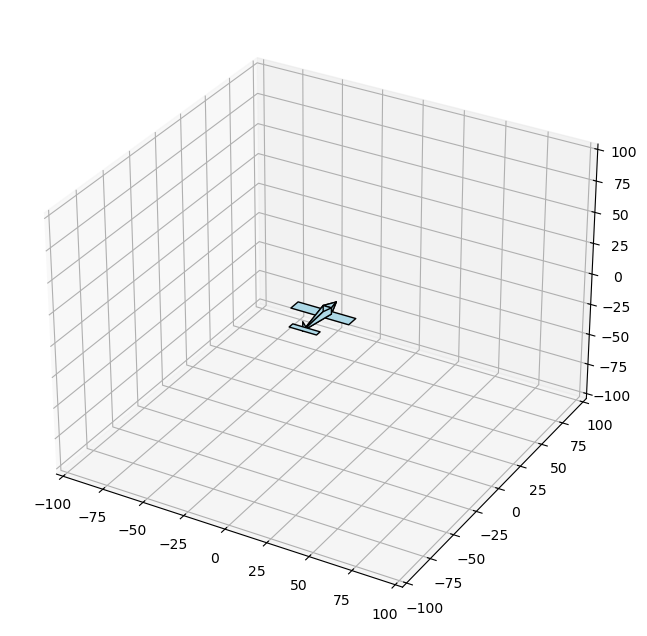

In [42]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

F = drawPlane(0, 0, 0, np.radians(0), np.radians(0), np.radians(0))
# Create 3D plot
fig = plt.figure(figsize=(8,8))
ax = fig.add_subplot(111, projection='3d')
# Set axis limits
ax.set_xlim([-100, 100])  # North
ax.set_ylim([-100, 100])  # East
ax.set_zlim([-100, 100])   # Down (remember, positive down in NED)

for face in F:
    poly = Poly3DCollection([face], facecolors='lightblue', linewidths=1, edgecolors='black')
    ax.add_collection3d(poly)

